In [1]:
import pandas as pd

ventas = pd.read_csv(r"C:\Users\iccni\OneDrive\Documentos\ESTUDIOS\IBM CURSO IA\TRABAJO EN GRUPO - PROYECTO\BASE DE DATOS\Ventas.csv", encoding = "utf-8", sep=";")
detalle = pd.read_csv(r"C:\Users\iccni\OneDrive\Documentos\ESTUDIOS\IBM CURSO IA\TRABAJO EN GRUPO - PROYECTO\BASE DE DATOS\Detalle_ventas.csv",encoding="utf-8",sep=";")
productos = pd.read_csv(r"C:\Users\iccni\OneDrive\Documentos\ESTUDIOS\IBM CURSO IA\TRABAJO EN GRUPO - PROYECTO\BASE DE DATOS\Productos.csv", encoding = "utf-8", sep=";")
resenas = pd.read_csv(r"C:\Users\iccni\OneDrive\Documentos\ESTUDIOS\IBM CURSO IA\TRABAJO EN GRUPO - PROYECTO\BASE DE DATOS\Reseña.csv", encoding="utf-8", sep=";")
envios = pd.read_csv(r"C:\Users\iccni\OneDrive\Documentos\ESTUDIOS\IBM CURSO IA\TRABAJO EN GRUPO - PROYECTO\BASE DE DATOS\Envíos.csv", encoding ="utf-8", sep=";")

for df in [ventas, detalle, productos, envios, resenas]: df.columns = df.columns.str.strip().str.lower()

envios['fecha_hs_envio'] = pd.to_datetime(envios['fecha_hs_envio'])
envios['fecha_hs_entrega'] = pd.to_datetime(envios['fecha_hs_entrega'])
envios['dias_demora'] = (envios['fecha_hs_entrega'] - envios['fecha_hs_envio']).dt.days

# 2. Filtro de Calidad (Limpieza de fechas malas: negativas o >100 días)
envios_limpios = envios[(envios['dias_demora'] >= 0) & (envios['dias_demora'] < 100)].copy()

print(resenas.head)

<bound method NDFrame.head of       id_reseña  id_producto  id_cliente  calificación
0    lkUU1GoThQ         90.0        62.0           3.0
1    prDwXbqNZS         82.0        49.0           3.0
2    zWkzp7HsbW         39.0        20.0           2.0
3    G3uU45fRTU         70.0        36.0           0.0
4    BNDt9TwuEV         22.0        56.0           3.0
..          ...          ...         ...           ...
338         NaN          NaN         NaN           NaN
339         NaN          NaN         NaN           NaN
340         NaN          NaN         NaN           NaN
341         NaN          NaN         NaN           NaN
342         NaN          NaN         NaN           NaN

[343 rows x 4 columns]>


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Objetivo : Predecir o clasificar

Predecir posibles demoras en las entregas

Algoritmo : Regresión Lineal

En este caso es la selección más óptima teniendo en cuenta que se busca identificar si las demoras en cuanto aumentaran a futuro y esto puede causar cambios negativos en la calificación.

Es posible aplicar un modelo de CLustering, para identificar los clientes que tengo de acuerdo a la calificación que han brindado,

Modelo Tiempos - RL

In [3]:
# 1. Preparar los datos (convertir fechas a numérico para regresión)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split


envios_limpios['envio_ts']   = envios_limpios['fecha_hs_envio'].astype('int64') // 10**9 
envios_limpios['entrega_ts'] = envios_limpios['fecha_hs_entrega'].astype('int64') // 10**9

x = envios_limpios[['envio_ts','entrega_ts']]  #se convirtieron datos de fechas a númericos
y = envios_limpios['dias_demora']

# 2. Divirlos
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# 3. Crear el modelo
modelo_enviosl = LinearRegression()

# 4. Entrenar modelo
modelo_enviosl.fit(x_train, y_train)

# 5. Evaluar
y_pred = modelo_enviosl.predict(x_test)

# 6. métricas
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# 7. Mostrar resultados
print("\nMétricas")
print(f"Error cuadrático (MSE): {mse:.2f}")
print(f"Raíz del MSE (RMSE): {rmse:.2f}")
print(f"Primeras predicciones: {y_pred[:10]}")
print(f"Primeras respuestas: {y_test[:10].values}")

# 8. Coeficientes e intercepto
print(f"\nCoeficiente envio_ts: {modelo_enviosl.coef_[0]}")
print(f"Coeficiente entrega_ts: {modelo_enviosl.coef_[1]}")
print(f"Intercepto: {modelo_enviosl.intercept_}")


Métricas
Error cuadrático (MSE): 0.09
Raíz del MSE (RMSE): 0.30
Primeras predicciones: [19.80006971 68.63571482 11.20163363 47.44504698  4.10036941 30.770854
 34.6309014 ]
Primeras respuestas: [20 69 11 47  4 31 35]

Coeficiente envio_ts: -1.1525119312107586e-05
Coeficiente entrega_ts: 1.1524543908363508e-05
Intercepto: 0.7237991158253863



Métricas
Error cuadrático (MSE): 0.09
Raíz del MSE (RMSE): 0.30
Primeras predicciones: [19.80006971 68.63571482 11.20163363 47.44504698  4.10036941 30.770854
 34.6309014 ]
Primeras respuestas: [20 69 11 47  4 31 35]

Coeficiente envio_ts: -1.1525119312107586e-05
Coeficiente entrega_ts: 1.1524543908363508e-05
Intercepto: 0.7237991158253863

Coeficiente envio_ts: -1.1525119312107586e-05
Coeficiente entrega_ts: 1.1524543908363508e-05
Intercepto: 0.7237991158253863


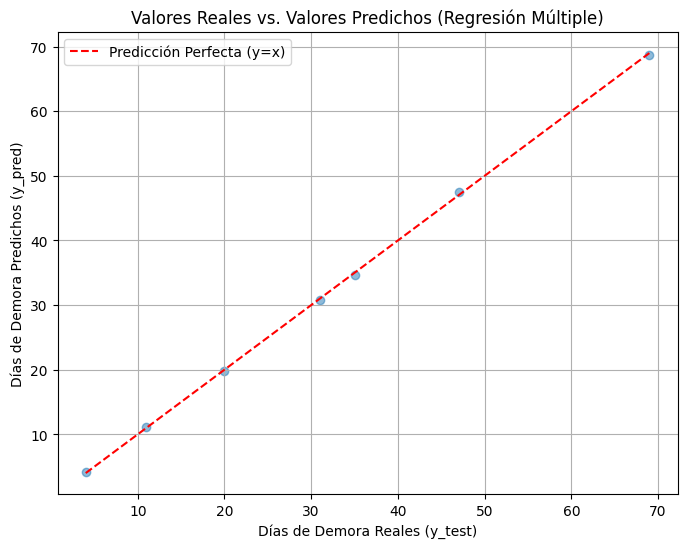

In [4]:
# 6. métricas
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# 7. Mostrar resultados
print("\nMétricas")
print(f"Error cuadrático (MSE): {mse:.2f}")
print(f"Raíz del MSE (RMSE): {rmse:.2f}")
print(f"Primeras predicciones: {y_pred[:10]}")
print(f"Primeras respuestas: {y_test[:10].values}")

# 8. Coeficientes e intercepto
print(f"\nCoeficiente envio_ts: {modelo_enviosl.coef_[0]}")
print(f"Coeficiente entrega_ts: {modelo_enviosl.coef_[1]}")
print(f"Intercepto: {modelo_enviosl.intercept_}")

# 8. Coeficientes e intercepto
print(f"\nCoeficiente envio_ts: {modelo_enviosl.coef_[0]}")
print(f"Coeficiente entrega_ts: {modelo_enviosl.coef_[1]}")
print(f"Intercepto: {modelo_enviosl.intercept_}")

# ========================================================
# 9. Código para graficar: Valores Reales vs. Predichos
# ========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Graficar los puntos de dispersión
plt.scatter(y_test, y_pred, alpha=0.5)

# Graficar la línea de identidad (y=x), que representa una predicción perfecta
# Limitamos los ejes para que la línea se vea bien.
lims = [min(min(y_test), min(y_pred)), max(max(y_test), max(y_pred))]
plt.plot(lims, lims, '--', color='red', label='Predicción Perfecta (y=x)')

plt.title('Valores Reales vs. Valores Predichos (Regresión Múltiple)')
plt.xlabel('Días de Demora Reales (y_test)')
plt.ylabel('Días de Demora Predichos (y_pred)')
plt.legend()
plt.grid(True)
plt.show()


Modelo Calificación - CL

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Preparar los datos (usar 2D) y eliminar filas con NaN
X = resenas[['calificación']].copy()  # DataFrame, shape (n_samples, 1)
X_clean = X.dropna()  # KMeans no acepta X solo

# 2. Crear el modelo
modeloCL = KMeans(n_clusters=3, random_state=42)

# 3. Entrenar el modelo con los datos limpios
modeloCL.fit(X_clean)

# 4. Anexar el cluster del df-original
resenas['grupo'] = pd.NA
resenas.loc[X_clean.index, 'grupo'] = modeloCL.labels_

# 5. Explorar
print(f"Cantidad de grupos: {modeloCL.n_clusters}")
print("\nDistribución")
print(resenas['grupo'].value_counts().sort_index())

print("\nCentroides de cada grupo (calificación)")
for i, c in enumerate(modeloCL.cluster_centers_):
    print(f"Grupo {i}: calificación ({c[0]:.2f})")

# 6. Evaluar
inercia = modeloCL.inertia_
print(f"\nInercia: {inercia:,.0f}")
# silhouette_score requiere datos sin NaN y al menos 2 clusters con muestras
if len(X_clean) >= 2 and len(set(modeloCL.labels_)) > 1:
    silhouette = silhouette_score(X_clean, modeloCL.labels_)
    print(f"Silhouette: {silhouette:.2f}")
else:
    print("Silhouette: no disponible (datos insuficientes)")

Cantidad de grupos: 3

Distribución
grupo
0    63
1    36
2    21
Name: count, dtype: int64

Centroides de cada grupo (calificación)
Grupo 0: calificación (3.81)
Grupo 1: calificación (2.00)
Grupo 2: calificación (0.95)

Inercia: 37
Silhouette: 0.71


Cantidad de grupos: 3

Distribución
grupo
0    63
1    36
2    21
Name: count, dtype: int64

Centroides de cada grupo (calificación)
Grupo 0: calificación (3.81)
Grupo 1: calificación (2.00)
Grupo 2: calificación (0.95)

Inercia: 37
Silhouette: 0.71


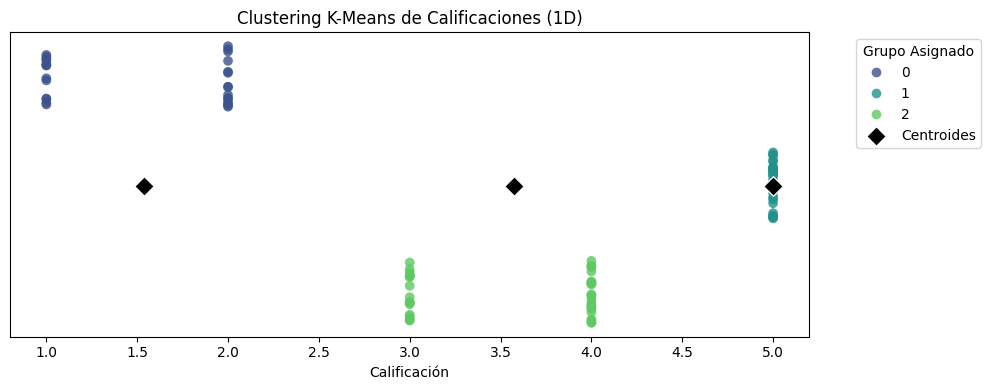

In [6]:
#Para graficar el clustering en esta caso 1D, se hizo necesario consultar con IA, identificando que aunque es posible realizarlo, no tiene el mismo enfoque que un grafico 2D o 3D.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Necesario para los datos de ejemplo si ejecutas todo el script

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Preparar los datos (usar 2D) y eliminar filas con NaN
X = resenas[['calificación']].copy()  # DataFrame, shape (n_samples, 1)
X_clean = X.dropna()  # KMeans no acepta X solo

# 2. Crear el modelo
modeloCL = KMeans(n_clusters=3, random_state=42)

# 3. Entrenar el modelo con los datos limpios
modeloCL.fit(X_clean)

# 4. Anexar el cluster del df-original
resenas['grupo'] = pd.NA
resenas.loc[X_clean.index, 'grupo'] = modeloCL.labels_

# 5. Explorar
print(f"Cantidad de grupos: {modeloCL.n_clusters}")
print("\nDistribución")
print(resenas['grupo'].value_counts().sort_index())

print("\nCentroides de cada grupo (calificación)")
for i, c in enumerate(modeloCL.cluster_centers_):
    print(f"Grupo {i}: calificación ({c[0]:.2f})")

# 6. Evaluar
inercia = modeloCL.inertia_
print(f"\nInercia: {inercia:,.0f}")
# silhouette_score requiere datos sin NaN y al menos 2 clusters con muestras
if len(X_clean) >= 2 and len(set(modeloCL.labels_)) > 1:
    silhouette = silhouette_score(X_clean, modeloCL.labels_)
    print(f"Silhouette: {silhouette:.2f}")
else:
    print("Silhouette: no disponible (datos insuficientes)")

np.random.seed(42)
data = {'calificación': np.random.choice([1, 2, 3, 4, 5], 100, p=[0.1, 0.1, 0.2, 0.3, 0.3])}
resenas = pd.DataFrame(data)

from sklearn.cluster import KMeans
X = resenas[['calificación']].copy()
X_clean = X.dropna()
modeloCL = KMeans(n_clusters=3, random_state=42, n_init=10)
modeloCL.fit(X_clean)
resenas['grupo'] = pd.NA
resenas.loc[X_clean.index, 'grupo'] = modeloCL.labels_
# --------------------------------------------------------------------------------------------------

# Convertir la columna 'grupo' a tipo categórico para que Seaborn la maneje mejor
resenas['grupo'] = resenas['grupo'].astype('category')

# --- Código para generar el gráfico ---
plt.figure(figsize=(10, 4)) # Hacemos el gráfico más ancho y bajo

# 1. Strip Plot (Gráfico de franjas)
# Visualiza cada punto individual, coloreado por su grupo
sns.stripplot(data=resenas, x='calificación', hue='grupo', jitter=0.25, palette='viridis', dodge=True, s=7, alpha=0.8)

# 2. Resaltar los centroides (opcional, pero útil)
centers = modeloCL.cluster_centers_
# Creamos un pequeño DataFrame temporal para graficar los centroides fácilmente
centers_df = pd.DataFrame({'calificación': centers.flatten(), 'grupo': [f'Grupo {i}' for i in range(len(centers))]})

# Graficar los centroides como puntos grandes y negros
plt.scatter(x=centers.flatten(), y=[0]*len(centers), marker='D', s=100, color='black', edgecolors='white', zorder=10, label='Centroides')


plt.title('Clustering K-Means de Calificaciones (1D)')
plt.xlabel('Calificación')
# Eliminar el eje Y ya que no tiene significado en este gráfico 1D
plt.yticks([])
plt.ylabel('')
plt.legend(title='Grupo Asignado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()